# TikTok Video Engagement Prediction

## Competition Objective

The goal of this competition is to predict the cumulative number of views
a TikTok video will receive by Day 30, using only information available
during the first five days after publication.

The available data includes:

- Video metadata
- Creator statistics
- Daily engagement metrics from Days 0–5

The competition metric is **Root Mean Squared Error (RMSE)**, where lower
values indicate better predictive performance.

Because the target is highly skewed, the analysis focuses on understanding
early engagement patterns, creator characteristics, and the distribution
of Day-30 views before building predictive models.

## Table of Contents

1. Setup
2. Data Loading
3. Initial Data Inspection
   - 3.1 Quick Look at Each Dataset
   - 3.2 Data Info
   - 3.3 Target Variable Analysis
   - 3.4 Engagement Analysis
   - 3.5 Creators Analysis
   - 3.6 Engagement Coverage Check
4. Feature Engineering
   - 4.1 Pivot Engagement Data
   - 4.2 Build Engagement Features
   - 4.3 Merge All Datasets (As-Of)
5. Final Dataset Overview
   - 5.1 Correlation Matrix
   - 5.2 Outlier Analysis
6. Save Clean Dataset
7. Conclusions & Next Steps

## 1. Setup

We import the libraries required for data loading, exploratory analysis,
feature engineering, and visualization.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Data Loading

The competition data is provided across several tables:

| File | Description |
|---|---|
| `train_videos.csv` | Training videos with metadata + target |
| `test_videos.csv` | Test videos with metadata only |
| `engagement_daily.csv` | Daily engagement metrics (video-day level) |
| `creators_daily.csv` | Daily creator statistics (creator-day level) |
| `sample_submission.csv` | Submission format reference |

We load the raw tables first and inspect their structure before
performing any transformations.

In [2]:
DATA_RAW = Path('../data/raw')

train = pd.read_csv(DATA_RAW / 'train_videos.csv')
test = pd.read_csv(DATA_RAW / 'test_videos.csv')
engagement = pd.read_csv(DATA_RAW / 'engagement_daily.csv')
creators = pd.read_csv(DATA_RAW / 'creators_daily.csv')
sample_sub = pd.read_csv(DATA_RAW / 'sample_submission.csv')

print(f"Train shape:      {train.shape}")
print(f"Test shape:       {test.shape}")
print(f"Engagement shape: {engagement.shape}")
print(f"Creators shape:   {creators.shape}")
print(f"Sample sub shape: {sample_sub.shape}")

Train shape:      (12000, 27)
Test shape:       (3001, 26)
Engagement shape: (79489, 10)
Creators shape:   (252166, 7)
Sample sub shape: (3001, 2)


### Section 2.1 — Data Overview

**Dataset Sizes:**
- **Train**: 12,000 videos × 27 columns
- **Test**: 3,001 videos × 26 columns
- **Engagement**: 79,489 rows (video-day level)
- **Creators**: 252,166 rows (creator-day level)

**Key Observation:**
The training set contains 12,000 videos, while the competition test set
contains 3,001 videos. Engagement data is stored at the video-day level,
while creator statistics are stored at the creator-day level. Both tables
require aggregation or temporal alignment before they can be used as
video-level features.

## 3. Initial Data Inspection

We inspect the columns, data types, missing values, and basic structure
of each dataset before feature engineering.

This step helps identify missing fields and differences between the
training and test tables.

In [3]:
# ============================================
# Quick Look at Each Dataset
# ============================================
print("=" * 60)
print("TRAIN VIDEOS")
print("=" * 60)
display(train.head())
print(f"\nColumns: {list(train.columns)}")

print("\n" + "=" * 60)
print("TEST VIDEOS")
print("=" * 60)
display(test.head())
print(f"\nColumns: {list(test.columns)}")

print("\n" + "=" * 60)
print("ENGAGEMENT DAILY")
print("=" * 60)
display(engagement.head())
print(f"\nColumns: {list(engagement.columns)}")

print("\n" + "=" * 60)
print("CREATORS DAILY")
print("=" * 60)
display(creators.head())
print(f"\nColumns: {list(creators.columns)}")

TRAIN VIDEOS


,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear,target_day30_views
0,7389777708642798891,6823500943611528198,2024-07-09 18:11:50,2024-07-09,61.230,540p,en,1,0.0,0,...,4.0,6.532745,Lifestyle,0.003960,0.790962,0.017963,0.002873,0.004761,0.001092,1371
1,7414315783221693739,6851716737763886085,2024-09-13 21:12:02,2024-09-13,58.095,540p,en,1,0.0,0,...,6.0,4.148378,Beauty_Fashion,0.004058,0.767556,0.003882,0.012160,0.019463,0.001298,1184
2,7408397785503943942,6809119722295968773,2024-08-28 22:27:16,2024-08-28,7.431,720p,en,1,0.0,0,...,4.0,0.000000,Life_hacks_Personal_growth,0.003275,0.849156,0.003241,0.007868,0.005667,0.003849,638
3,7406460852611681567,6790225026127627269,2024-08-23 17:11:01,2024-08-23,15.046,540p,un,0,0.0,0,...,0.0,0.000000,Beauty_Fashion,0.004971,0.612373,0.006764,0.010911,0.066338,0.001878,312
4,7428770082219756831,2033984,2024-10-22 20:02:15,2024-10-22,7.895,540p,en,1,0.0,0,...,NaN,NaN,Beauty_Fashion,0.022163,0.006064,0.008672,0.041306,0.474281,0.022709,180



Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear', 'target_day30_views']

TEST VIDEOS


,video_id,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,...,question_count,hashtag_count,speaking_rate,topic,anger,joy,surprise,sadness,disgust,fear
0,7400582591771938090,6986770031481095173,2024-08-07 21:00:13,2024-08-07,10.100,540p,un,0,0.0,0,...,0.0,2.0,3.564356,Life_hacks_Personal_growth,0.002676,0.938924,0.005082,0.002898,0.009154,0.000414
1,7403167206978374958,6761640179813254150,2024-08-14 20:09:53,2024-08-14,13.815,540p,un,0,1.0,0,...,0.0,5.0,0.000000,Dance_Music,0.003034,0.840657,0.005514,0.035231,0.010021,0.000603
2,7435124823820356906,6926128790248080390,2024-11-08 22:01:44,2024-11-08,10.600,540p,un,0,0.0,0,...,NaN,NaN,NaN,Life_hacks_Personal_growth,0.013941,0.821651,0.003380,0.018616,0.032773,0.000685
3,7409800970143714606,6930420307368199173,2024-09-01 17:12:16,2024-09-01,38.289,540p,en,1,0.0,0,...,0.0,39.0,3.708637,Lifestyle,0.002326,0.958039,0.002441,0.003065,0.005616,0.000298
4,7410935177553333550,6880023927025468421,2024-09-04 18:33:33,2024-09-04,14.883,540p,en,1,0.0,0,...,0.0,6.0,5.240879,Beauty_Fashion,0.003002,0.906478,0.004138,0.002237,0.003371,0.001028



Columns: ['video_id', 'author_id', 'create_time', 'create_date', 'duration', 'ratio', 'desc_language', 'is_english', 'created_by_ai', 'is_ads', 'music_selected_from', 'music_author', 'music_owner_id', 'music_id', 'word_count', 'emoji_count', 'question_count', 'hashtag_count', 'speaking_rate', 'topic', 'anger', 'joy', 'surprise', 'sadness', 'disgust', 'fear']

ENGAGEMENT DAILY


,video_id,date,days_since_post,play_count,like_count,comment_count,share_count,collect_count,download_count,whatsapp_share_count
0,7384086821132717358,2024-06-24,0,105696,6249,23,1113,1737,59,5
1,7384086821132717358,2024-06-25,1,330084,25291,71,3689,6421,214,25
2,7384086821132717358,2024-06-26,2,390753,32925,93,4476,8082,272,30
3,7384086821132717358,2024-06-27,3,464862,45741,137,5756,10699,358,33
4,7384086821132717358,2024-06-28,4,475386,46896,143,5907,10926,366,33



Columns: ['video_id', 'date', 'days_since_post', 'play_count', 'like_count', 'comment_count', 'share_count', 'collect_count', 'download_count', 'whatsapp_share_count']

CREATORS DAILY


,author_id,date,follower_count,following_count,total_favorited,video_count,enterprise_verified
0,10245051,2024-06-27,1704.0,1039.0,75987,83.0,NaN
1,10245051,2024-06-28,1704.0,1039.0,76018,83.0,NaN
2,10245051,2024-06-29,1704.0,1039.0,76024,83.0,NaN
3,10245051,2024-06-30,1704.0,1039.0,76025,83.0,NaN
4,10245051,2024-07-01,1704.0,1039.0,76029,83.0,NaN



Columns: ['author_id', 'date', 'follower_count', 'following_count', 'total_favorited', 'video_count', 'enterprise_verified']


### Section 3.2 — Data Types and Missing Values

We check data types and missing values across all four tables.
This helps determine which features need imputation and which
columns should be dropped.

In [4]:
# ============================================
# Data Info
# ============================================
for name, df in [('train', train), ('test', test), 
                 ('engagement', engagement), ('creators', creators)]:
    print(f"\n{'=' * 60}")
    print(f"{name.upper()}")
    print(f"{'=' * 60}")
    print(f"Shape: {df.shape}")
    print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
    print(f"Dtypes:\n{df.dtypes}")


TRAIN
Shape: (12000, 27)
Missing values:
music_selected_from     121
music_author             21
music_owner_id         2972
music_id                  1
word_count             4047
emoji_count            4047
question_count         4047
hashtag_count          4047
speaking_rate          4047
anger                    42
joy                      42
surprise                 42
sadness                  42
disgust                  42
fear                     42
dtype: int64
Dtypes:
video_id                 int64
author_id                int64
create_time                str
create_date                str
duration               float64
ratio                      str
desc_language              str
is_english               int64
created_by_ai          float64
is_ads                   int64
music_selected_from        str
music_author               str
music_owner_id         float64
music_id               float64
word_count             float64
emoji_count            float64
question_count       

### Section 3.2 — Key Data-Quality Findings

**Missing Values:**
Several video-level features contain substantial missingness, especially
the text-related features such as `word_count`, `emoji_count`,
`question_count`, `hashtag_count`, and `speaking_rate`.

**Creator Table Issue:**
The creator field `enterprise_verified` contains no non-null values in
the provided creator table, so it does not provide usable information
and should not be treated as a predictive feature.

**Strategy:**
Missing values will be handled during the modeling pipeline rather than
being removed from the dataset.

### Section 3.3 — Target Variable Analysis

The target variable `target_day30_views` is analyzed to understand its
distribution, skewness, and range. This is critical because RMSE is
sensitive to extreme values.

TARGET: target_day30_views

Basic Statistics:
count    1.200000e+04
mean     2.922860e+04
std      2.752131e+05
min      0.000000e+00
25%      3.440000e+02
50%      6.680000e+02
75%      3.016500e+03
max      1.631055e+07
Name: target_day30_views, dtype: float64

Skewness: 29.133
Kurtosis: 1268.776


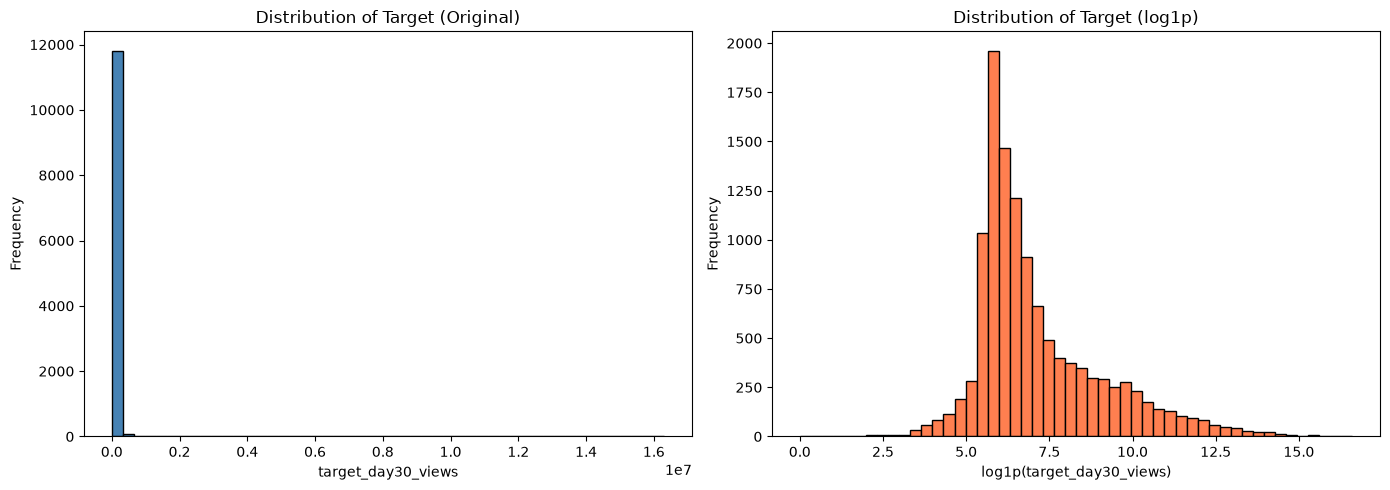

In [5]:
# ============================================
# Target Variable Analysis
# ============================================
print("=" * 60)
print("TARGET: target_day30_views")
print("=" * 60)

print("\nBasic Statistics:")
print(train['target_day30_views'].describe())

print(f"\nSkewness: {train['target_day30_views'].skew():.3f}")
print(f"Kurtosis: {train['target_day30_views'].kurtosis():.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
axes[0].hist(train['target_day30_views'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Distribution of Target (Original)')
axes[0].set_xlabel('target_day30_views')
axes[0].set_ylabel('Frequency')

# Log
axes[1].hist(np.log1p(train['target_day30_views']), bins=50, color='coral', edgecolor='black')
axes[1].set_title('Distribution of Target (log1p)')
axes[1].set_xlabel('log1p(target_day30_views)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

### Section 3.3 — Key Insight

The Day-30 view target is **extremely right-skewed**.

- **Median**: 668 views
- **Mean**: 29,229 views
- **Maximum**: 16,310,546 views
- **Skewness**: 29.133

The large gap between the median and mean indicates that a relatively
small number of videos receive exceptionally high view counts.

**Implication:** RMSE will be particularly sensitive to large prediction
errors, so modeling strategies must account for the upper tail.

### Section 3.4 — Engagement Daily Analysis

We analyze the engagement table to understand:

- Day coverage per video
- Distribution of engagement metrics
- Missing Day 0 entries

In [6]:
# ============================================
# Engagement Analysis (Days 0-5)
# ============================================
print("=" * 60)
print("ENGAGEMENT DAILY - Overview")
print("=" * 60)

# Days distribution
print("\nDays since post distribution:")
print(engagement['days_since_post'].value_counts().sort_index())

# Unique videos
n_videos_eng = engagement['video_id'].nunique()
n_videos_train = train['video_id'].nunique()
print(f"\nUnique videos in engagement: {n_videos_eng}")
print(f"Unique videos in train:      {n_videos_train}")
print(f"Coverage: {n_videos_eng / n_videos_train * 100:.1f}%")

# Rows per video
rows_per_video = engagement.groupby('video_id').size()
print(f"\nRows per video:")
print(rows_per_video.describe())

# Engagement stats
print("\n" + "=" * 60)
print("ENGAGEMENT METRICS STATISTICS")
print("=" * 60)
print(engagement[['play_count', 'like_count', 'comment_count', 
                  'share_count', 'collect_count', 'download_count', 
                  'whatsapp_share_count']].describe().T)

ENGAGEMENT DAILY - Overview

Days since post distribution:
days_since_post
0     5638
1    14750
2    14726
3    14768
4    14856
5    14751
Name: count, dtype: int64

Unique videos in engagement: 15000
Unique videos in train:      12000
Coverage: 125.0%

Rows per video:
count    15000.000000
mean         5.299267
std          0.551356
min          1.000000
25%          5.000000
50%          5.000000
75%          6.000000
max          6.000000
dtype: float64

ENGAGEMENT METRICS STATISTICS
                        count          mean            std  min    25%    50%  \
play_count            79489.0  13991.800689  145337.531340  0.0  273.0  458.0   
like_count            79489.0   1311.813899   14571.466661  0.0   14.0   36.0   
comment_count         79489.0     22.337078     225.819114  0.0    0.0    2.0   
share_count           79489.0    103.941577    3162.592505  0.0    0.0    0.0   
collect_count         79489.0     89.227616    1294.691795  0.0    0.0    1.0   
download_count      

### Section 3.4 — Key Insight

The engagement table contains **15,000 unique videos**, while the
training set contains **12,000 videos**.

The number of observations per video varies from **1 to 6 days**, with an
average of approximately **5.3 observations per video**.

**Implication:** Not every video has a complete Day 0–5 history.
Missing daily observations must be preserved and handled carefully when
creating daily engagement features.

### Section 3.5 — Creators Daily Analysis

We analyze creator statistics to understand:

- Number of unique creators
- Distribution of follower counts, video counts, and total favorites
- Coverage of the `enterprise_verified` field

In [7]:
# ============================================
# Creators Analysis
# ============================================
print("=" * 60)
print("CREATORS DAILY - Overview")
print("=" * 60)

print(f"Unique creators: {creators['author_id'].nunique()}")
print(f"Date range: {creators['date'].min()} to {creators['date'].max()}")

# Rows per creator
rows_per_creator = creators.groupby('author_id').size()
print(f"\nRows per creator:")
print(rows_per_creator.describe())

# Creator stats
print("\n" + "=" * 60)
print("CREATOR STATS")
print("=" * 60)
print(creators[['follower_count', 'following_count', 
                'total_favorited', 'video_count']].describe().T)

# Check enterprise_verified
print("\n" + "=" * 60)
print("enterprise_verified")
print("=" * 60)
print(f"Non-null values: {creators['enterprise_verified'].notna().sum()}")
print(f"Unique values: {creators['enterprise_verified'].unique()}")

CREATORS DAILY - Overview
Unique creators: 1671
Date range: 2024-06-24 to 2024-12-09

Rows per creator:
count    1671.000000
mean      150.907241
std        17.196167
min        48.000000
25%       151.000000
50%       158.000000
75%       160.000000
max       161.000000
dtype: float64

CREATOR STATS
                    count          mean           std    min      25%  \
follower_count   252000.0  1.150920e+05  5.302737e+05  897.0   3602.0   
following_count  252000.0  2.008529e+03  2.674423e+03    0.0    301.0   
total_favorited  252166.0  4.523682e+06  2.166221e+07    0.0  47419.0   
video_count      252141.0  9.907009e+02  1.066611e+03    0.0    362.0   

                      50%         75%          max  
follower_count    10519.0    40924.00   12551915.0  
following_count     772.0     2486.00      10000.0  
total_favorited  239626.5  1289239.75  497437006.0  
video_count         678.0     1273.00      19974.0  

enterprise_verified
Non-null values: 0
Unique values: [nan]


### Section 3.5 — Key Insight

Creator statistics vary substantially across creators:

- **Follower count**: 897 → 12.5M+
- **Total favorites**: 0 → ~497M

The creator table also contains **repeated daily snapshots**, which means
creator features must be aligned with the video's publication date
rather than simply taking an arbitrary or latest snapshot.

**Strategy:** Use an as-of merge (`merge_asof` with `direction='backward'`)
to fetch the latest creator snapshot on or before the video's `create_date`.

### Section 3.6 — Engagement Coverage Check

We verify how many training videos have engagement data and how many days
of engagement history each video has.

In [8]:
# ============================================
# QUICK CHECK: Engagement Coverage
# ============================================
print("=" * 60)
print("ENGAGEMENT COVERAGE CHECK")
print("=" * 60)

# === 1. Check which videos in train have engagement ===
train_videos = set(train['video_id'])
eng_videos = set(engagement['video_id'])

print(f"Videos in train:      {len(train_videos):,}")
print(f"Videos in engagement: {len(eng_videos):,}")
print(f"Overlap:              {len(train_videos & eng_videos):,}")
print(f"Train without engagement: {len(train_videos - eng_videos):,}")

# === 2. Check day coverage per video ===
days_per_video = engagement.groupby('video_id')['days_since_post'].nunique()
print(f"\nDays per video:")
print(f"  Mean:   {days_per_video.mean():.2f}")
print(f"  Median: {days_per_video.median():.0f}")
print(f"  Min:    {days_per_video.min()}")
print(f"  Max:    {days_per_video.max()}")
print(f"  Videos with < 6 days: {(days_per_video < 6).sum():,}")

ENGAGEMENT COVERAGE CHECK


Videos in train:      12,000
Videos in engagement: 15,000
Overlap:              11,999
Train without engagement: 1

Days per video:
  Mean:   5.30
  Median: 5
  Min:    1
  Max:    6
  Videos with < 6 days: 9,830


## 4. Feature Engineering

The daily engagement table is transformed into video-level features.

The features describe three aspects of early performance:

1. **Engagement level** — how many views and interactions the video received.
2. **Growth** — how engagement changes across the observed days.
3. **Engagement intensity** — interactions relative to the number of views.

Because some videos do not contain observations for every day, missing
daily values are preserved during the initial feature construction and
handled explicitly where ratios or growth rates are calculated.

### Section 4.1 — Pivot Engagement Data

We pivot the long-format engagement table (video-day level) into a wide
format (one row per video, one column per day per metric).

Additionally, we create completeness features:
- `n_days`: number of days with observations per video
- `has_day0`: whether Day 0 is present
- `has_day5`: whether Day 5 is present
- `play_count_day5_filled`: Day 5 play count, forward-filled if missing

In [9]:
# ============================================
# FEATURE ENGINEERING - Step 1: Pivot Engagement
# ============================================
print("=" * 60)
print("PIVOTING ENGAGEMENT DATA")
print("=" * 60)

def pivot_metric(df, metric_name):
    pivot = df.pivot_table(
        index='video_id', 
        columns='days_since_post', 
        values=metric_name,
        aggfunc='first'
    )
    pivot.columns = [f'{metric_name}_day{c}' for c in pivot.columns]
    return pivot

metrics = ['play_count', 'like_count', 'comment_count', 
           'share_count', 'collect_count', 'download_count', 
           'whatsapp_share_count']

pivoted_dfs = []
for metric in metrics:
    pivoted_dfs.append(pivot_metric(engagement, metric))

engagement_pivot = pd.concat(pivoted_dfs, axis=1).reset_index()

# === NEW: Completeness features ===
# عدد الأيام المتاحة لكل فيديو
n_days_per_video = (
    engagement.groupby('video_id')['days_since_post']
    .nunique()
    .rename('n_days')
)
engagement_pivot = engagement_pivot.merge(
    n_days_per_video, on='video_id', how='left'
)

# هل day0 موجود؟
engagement_pivot['has_day0'] = (
    engagement_pivot['play_count_day0'].notna().astype(int)
)

# هل day5 موجود؟
engagement_pivot['has_day5'] = (
    engagement_pivot['play_count_day5'].notna().astype(int)
)

# === FIX: Handle missing day5 by forward-filling from earlier days ===
# لو day5 ناقص، نستخدم آخر يوم متاح (day4، day3، ...)
day_cols = [f'play_count_day{i}' for i in range(6)]
engagement_pivot['play_count_day5_filled'] = (
    engagement_pivot[day_cols]
    .ffill(axis=1)  # forward fill من اليسار لليمين
    .iloc[:, -1]    # خد آخر عمود
)

print(f"Pivoted shape: {engagement_pivot.shape}")
print(f"Columns added: n_days, has_day0, has_day5, play_count_day5_filled")

# Check missing days
print("\nMissing values per day:")
for col in ['play_count_day0', 'play_count_day1', 'play_count_day2',
            'play_count_day3', 'play_count_day4', 'play_count_day5']:
    if col in engagement_pivot.columns:
        print(f"  {col}: {engagement_pivot[col].isnull().sum()}")

# Check the new features
print(f"\n--- Completeness Features ---")
print(f"n_days distribution:")
print(engagement_pivot['n_days'].value_counts().sort_index())
print(f"\nhas_day0: {engagement_pivot['has_day0'].mean()*100:.1f}% have it")
print(f"has_day5: {engagement_pivot['has_day5'].mean()*100:.1f}% have it")

engagement_pivot.head()

PIVOTING ENGAGEMENT DATA
Pivoted shape: (15000, 47)
Columns added: n_days, has_day0, has_day5, play_count_day5_filled

Missing values per day:
  play_count_day0: 9362
  play_count_day1: 250
  play_count_day2: 274
  play_count_day3: 232
  play_count_day4: 144
  play_count_day5: 249

--- Completeness Features ---
n_days distribution:
n_days
1       1
2       2
3      14
4     643
5    9170
6    5170
Name: count, dtype: int64

has_day0: 37.6% have it
has_day5: 98.3% have it


,video_id,play_count_day0,play_count_day1,play_count_day2,play_count_day3,play_count_day4,play_count_day5,like_count_day0,like_count_day1,like_count_day2,...,whatsapp_share_count_day0,whatsapp_share_count_day1,whatsapp_share_count_day2,whatsapp_share_count_day3,whatsapp_share_count_day4,whatsapp_share_count_day5,n_days,has_day0,has_day5,play_count_day5_filled
0,7384086821132717358,105696.0,330084.0,390753.0,464862.0,475386.0,478085.0,6249.0,25291.0,32925.0,...,5.0,25.0,30.0,33.0,33.0,34.0,6,1,1,478085.0
1,7384175589206265118,138.0,323.0,388.0,447.0,492.0,557.0,7.0,16.0,17.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,1,1,557.0
2,7384177529092951338,10524.0,11045.0,11290.0,11430.0,11610.0,11743.0,1388.0,1449.0,1465.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,1,1,11743.0
3,7384193780057984287,273.0,356.0,378.0,397.0,410.0,423.0,36.0,41.0,42.0,...,0.0,0.0,0.0,0.0,0.0,0.0,6,1,1,423.0
4,7384193851700956447,541.0,1414.0,1959.0,2258.0,2467.0,2697.0,16.0,32.0,36.0,...,1.0,1.0,1.0,1.0,1.0,1.0,6,1,1,2697.0


### Section 4.1 — Key Insight

After pivoting, each video is represented by one row with separate
columns for Days 0–5.

**Key observations:**
- **Day 0 is missing for ~62% of videos**, making it unreliable as the
  "first" observation.
- **Day 5 is present for ~98.3% of videos**, making it the most stable
  reference point.
- Only **37.6% of videos have Day 0**, so Day 1 is used as the first
  observation instead.

**Strategy:** Use `play_count_day5_filled` (forward-filled) as the
"final early engagement" indicator to handle missing Day 5 observations.

### Section 4.2 — Build Engagement Features

We construct three categories of features from the pivoted engagement data:

1. **Level features**: Total values at Day 5 and the max/mean/std across days.
2. **Growth features**: Ratios between days (e.g., day5/day1) and daily differences.
3. **Ratio features**: Interaction counts (like, comment, share) relative to play count.

In [10]:
# ============================================
# FEATURE ENGINEERING - Step 2: Build Features
# ============================================
print("=" * 60)
print("BUILDING FEATURES FROM ENGAGEMENT")
print("=" * 60)

def safe_divide(a, b):
    """Safely divide, return 0 if denominator is 0."""
    return np.where((b == 0) | pd.isna(b), 0, a / b)

# === 1. آخر يوم (day5) — الأقوى ===
feat = engagement_pivot[['video_id']].copy()

# Play metrics — استخدام play_count_day5_filled بدل play_count_day5
feat['play_last'] = engagement_pivot['play_count_day5_filled']
feat['play_first'] = engagement_pivot['play_count_day1']  # day1 بدل day0
feat['play_max'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                      'play_count_day3', 'play_count_day4',
                                      'play_count_day5']].max(axis=1)
feat['play_mean'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                       'play_count_day3', 'play_count_day4',
                                       'play_count_day5']].mean(axis=1)
feat['play_std'] = engagement_pivot[['play_count_day1', 'play_count_day2',
                                      'play_count_day3', 'play_count_day4',
                                      'play_count_day5']].std(axis=1)

# Growth ratios
feat['play_growth_5_1'] = safe_divide(
    engagement_pivot['play_count_day5'], 
    engagement_pivot['play_count_day1']
)
feat['play_growth_5_3'] = safe_divide(
    engagement_pivot['play_count_day5'], 
    engagement_pivot['play_count_day3']
)
feat['play_growth_3_1'] = safe_divide(
    engagement_pivot['play_count_day3'], 
    engagement_pivot['play_count_day1']
)

# Daily differences
feat['play_diff_5_4'] = engagement_pivot['play_count_day5'] - engagement_pivot['play_count_day4']
feat['play_diff_4_3'] = engagement_pivot['play_count_day4'] - engagement_pivot['play_count_day3']
feat['play_diff_3_2'] = engagement_pivot['play_count_day3'] - engagement_pivot['play_count_day2']

# === 2. Interaction Ratios (Day 5) ===
feat['like_ratio'] = safe_divide(engagement_pivot['like_count_day5'], 
                                  engagement_pivot['play_count_day5'])
feat['comment_ratio'] = safe_divide(engagement_pivot['comment_count_day5'], 
                                     engagement_pivot['play_count_day5'])
feat['share_ratio'] = safe_divide(engagement_pivot['share_count_day5'], 
                                   engagement_pivot['play_count_day5'])
feat['collect_ratio'] = safe_divide(engagement_pivot['collect_count_day5'], 
                                     engagement_pivot['play_count_day5'])
feat['download_ratio'] = safe_divide(engagement_pivot['download_count_day5'], 
                                      engagement_pivot['play_count_day5'])
feat['whatsapp_ratio'] = safe_divide(engagement_pivot['whatsapp_share_count_day5'], 
                                      engagement_pivot['play_count_day5'])

# === 3. Other metrics (Day 5) ===
feat['like_last'] = engagement_pivot['like_count_day5']
feat['comment_last'] = engagement_pivot['comment_count_day5']
feat['share_last'] = engagement_pivot['share_count_day5']
feat['collect_last'] = engagement_pivot['collect_count_day5']
feat['download_last'] = engagement_pivot['download_count_day5']
feat['whatsapp_last'] = engagement_pivot['whatsapp_share_count_day5']

# === 4. Total engagement ===
feat['total_engagement_last'] = (
    feat['like_last'] + feat['comment_last'] + feat['share_last'] +
    feat['collect_last'] + feat['download_last'] + feat['whatsapp_last']
)

feat['engagement_ratio'] = safe_divide(feat['total_engagement_last'], feat['play_last'])

# === 5. COMPLETENESS FEATURES ===
feat['n_days'] = engagement_pivot['n_days']
feat['has_day0'] = engagement_pivot['has_day0']
feat['has_day5'] = engagement_pivot['has_day5']
# ============================================
# ADVANCED ENGAGEMENT FEATURES (v2)
# ============================================
print("Building advanced features...")

# === 2. النمو النسبي (Relative Growth) ===
# كم ضعف نمو الفيديو من day1 إلى day5
feat['play_relative_growth'] = safe_divide(
    engagement_pivot['play_count_day5'],
    engagement_pivot['play_count_day1'] + 1
)

# === 3. متوسط النمو اليومي ===
feat['play_daily_growth'] = safe_divide(
    engagement_pivot['play_count_day5'] - engagement_pivot['play_count_day1'],
    4  # 4 أيام بين day1 و day5
)

# === 4. نسب يومية (Daily Ratios) ===
feat['play_ratio_5_4'] = safe_divide(
    engagement_pivot['play_count_day5'],
    engagement_pivot['play_count_day4'] + 1
)
feat['play_ratio_4_3'] = safe_divide(
    engagement_pivot['play_count_day4'],
    engagement_pivot['play_count_day3'] + 1
)

# === 5. مؤشر الفيرالية المبكر ===
# يجمع بين log للحجم و engagement ratio
feat['early_virality_score'] = (
    np.log1p(engagement_pivot['play_count_day5'].clip(lower=0)) * 
    feat['engagement_ratio']
)

# === 6. كفاءة النمو ===
# كم تفاعل نحتاج لكل view جديد
feat['growth_efficiency'] = safe_divide(
    feat['total_engagement_last'],
    engagement_pivot['play_count_day5'] - engagement_pivot['play_count_day1'] + 1
)

# === 7. استقرار التفاعل ===
# std/mean للتفاعل اليومي
feat['like_std_ratio'] = safe_divide(
    engagement_pivot[['like_count_day1', 'like_count_day2', 
                      'like_count_day3', 'like_count_day4', 
                      'like_count_day5']].std(axis=1),
    engagement_pivot[['like_count_day1', 'like_count_day2', 
                      'like_count_day3', 'like_count_day4', 
                      'like_count_day5']].mean(axis=1) + 1
)

# === 8. نسبة مثلثية (Triangular Growth) ===
# مؤشر على نموذج النمو (خطي vs لوغاريتمي)
feat['triangular_growth'] = safe_divide(
    engagement_pivot['play_count_day3'] * 2,
    engagement_pivot['play_count_day1'] + engagement_pivot['play_count_day5'] + 1
)

print(f"✅ Advanced features built")
print(f"Total features now: {feat.shape[1] - 1}")

print(f"Features built: {feat.shape[1] - 1}")
feat.head()

BUILDING FEATURES FROM ENGAGEMENT
Building advanced features...
✅ Advanced features built
Total features now: 36
Features built: 36


,video_id,play_last,play_first,play_max,play_mean,play_std,play_growth_5_1,play_growth_5_3,play_growth_3_1,play_diff_5_4,...,has_day0,has_day5,play_relative_growth,play_daily_growth,play_ratio_5_4,play_ratio_4_3,early_virality_score,growth_efficiency,like_std_ratio,triangular_growth
0,7384086821132717358,478085.0,330084.0,478085.0,427834.0,65359.566151,1.448374,1.028445,1.408314,2699.0,...,1,1,1.448369,37000.25,1.005675,1.022637,1.766440,0.436325,0.251502,1.150406
1,7384175589206265118,557.0,323.0,557.0,441.4,90.588631,1.724458,1.246085,1.383901,65.0,...,1,1,1.719136,58.50,1.129817,1.098214,0.238441,0.089362,0.069353,1.014756
2,7384177529092951338,11743.0,11045.0,11743.0,11423.6,272.941935,1.063196,1.027384,1.034857,133.0,...,1,1,1.063100,174.50,1.011369,1.015659,1.353435,2.426323,0.014908,1.003116
3,7384193780057984287,423.0,356.0,423.0,392.8,26.451843,1.188202,1.065491,1.115169,13.0,...,1,1,1.184874,16.75,1.029197,1.030151,0.729400,0.750000,0.010449,1.017949
4,7384193851700956447,2697.0,1414.0,2697.0,2159.0,497.276080,1.907355,1.194420,1.596888,230.0,...,1,1,1.906007,320.75,1.092788,1.092076,0.187474,0.049844,0.128267,1.098249


### Section 4.3 — Merge All Datasets (As-Of)

We merge:

1. **Train videos** with engagement features
2. **Creator features** using an as-of merge

The as-of merge ensures each video only receives creator statistics
available **on or before** its publication date, preventing future
data leakage.

In [11]:
# ============================================
# FEATURE ENGINEERING - Step 3: Merge All (AS-OF)
# ============================================
from pandas import merge_asof

print("=" * 60)
print("MERGING ALL DATASETS (AS-OF)")
print("=" * 60)

# === 1. Start with train ===
df = train.copy()
print(f"Train: {df.shape}")

# === 2. Merge engagement features ===
df = df.merge(feat, on='video_id', how='left')
print(f"After engagement merge: {df.shape}")

# === 3. Prepare creators (as-of merge) ===
# Convert dates to datetime
creators['date'] = pd.to_datetime(creators['date'])
df['create_date'] = pd.to_datetime(df['create_date'])

# Sort by date (required for merge_asof)
creators_sorted = creators.sort_values('date').reset_index(drop=True)
df_sorted = df.sort_values('create_date').reset_index(drop=True)

# === 4. merge_asof: for each video, get creator stats <= create_date ===
df_merged = merge_asof(
    df_sorted,
    creators_sorted[['author_id', 'date',
                     'follower_count', 'following_count',
                     'total_favorited', 'video_count']],
    left_on='create_date',
    right_on='date',
    by='author_id',
    direction='backward'   
)

# Drop the extra 'date' column
df_merged = df_merged.drop(columns=['date'])

print(f"After creators merge (as-of): {df_merged.shape}")
print(f"\nFinal shape: {df_merged.shape}")
print(f"\nVideos without creator match: {df_merged['follower_count'].isnull().sum()}")

print(f"\nMissing values (top 10):")
missing = df_merged.isnull().sum().sort_values(ascending=False).head(10)
print(missing)

# === Set index ===
df = df_merged.set_index('video_id')
print(f"\nFinal index: video_id")

df.head()

MERGING ALL DATASETS (AS-OF)
Train: (12000, 27)
After engagement merge: (12000, 63)
After creators merge (as-of): (12000, 67)

Final shape: (12000, 67)

Videos without creator match: 0

Missing values (top 10):
hashtag_count        4047
question_count       4047
emoji_count          4047
word_count           4047
speaking_rate        4047
music_owner_id       2972
play_diff_3_2         404
play_daily_growth     394
play_diff_5_4         317
play_diff_4_3         293
dtype: int64

Final index: video_id


,author_id,create_time,create_date,duration,ratio,desc_language,is_english,created_by_ai,is_ads,music_selected_from,...,play_ratio_5_4,play_ratio_4_3,early_virality_score,growth_efficiency,like_std_ratio,triangular_growth,follower_count,following_count,total_favorited,video_count
video_id,,,,,,,,,,,,,,,,,,,,,
7384281153810730282,6964376699194868741,2024-06-24 22:42:19,2024-06-24,17.051,540p,en,1,0.0,0,original,...,1.009897,1.012180,1.331632,1.173698,0.029754,1.037759,321943.0,78.0,45290122,4314.0
7384256742231674142,1355171,2024-06-24 21:07:52,2024-06-24,8.800,540p,en,1,0.0,0,single_song,...,0.996815,1.016234,0.955171,2.363636,0.010699,1.013201,27222.0,10000.0,329388,2076.0
7384240278447623454,6716318631842202629,2024-06-24 20:03:56,2024-06-24,41.267,540p,en,1,0.0,0,original,...,1.094988,1.088373,1.729913,0.463098,0.113304,1.003971,253717.0,34.0,19732791,1223.0
7384297959522929966,6964376699194868741,2024-06-24 23:47:36,2024-06-24,12.834,540p,en,1,0.0,0,original,...,1.006921,1.016424,0.759423,0.306209,0.064062,1.089725,321943.0,78.0,45290122,4314.0
7384219266125548842,6613162,2024-06-24 18:42:12,2024-06-24,4.550,540p,un,0,0.0,0,single_song,...,1.100000,1.035714,0.213719,0.142857,0.228218,1.000000,10485.0,287.0,321032,546.0


### Section 5.1 — Correlation Matrix

We compute the correlation matrix to identify features with strong linear
relationships to the target. This helps prioritize features for modeling.

CORRELATION MATRIX

TOP 25 FEATURES CORRELATED WITH TARGET
play_max                 0.970685
play_last                0.970681
play_mean                0.944955
play_daily_growth        0.938483
play_std                 0.937192
play_diff_3_2            0.893941
play_diff_4_3            0.889323
like_last                0.880009
total_engagement_last    0.859190
play_diff_5_4            0.813537
play_first               0.764924
collect_last             0.678167
share_last               0.639336
whatsapp_last            0.587106
comment_last             0.507607
download_last            0.401917
follower_count           0.262636
total_favorited          0.254296
like_std_ratio           0.240253
early_virality_score     0.167033
play_growth_5_1          0.133226
question_count           0.112427
play_growth_3_1          0.111683
word_count               0.106985
speaking_rate            0.071242
Name: target_day30_views, dtype: float64

TOP 10 NEGATIVE CORRELATIONS
created_by_ai       

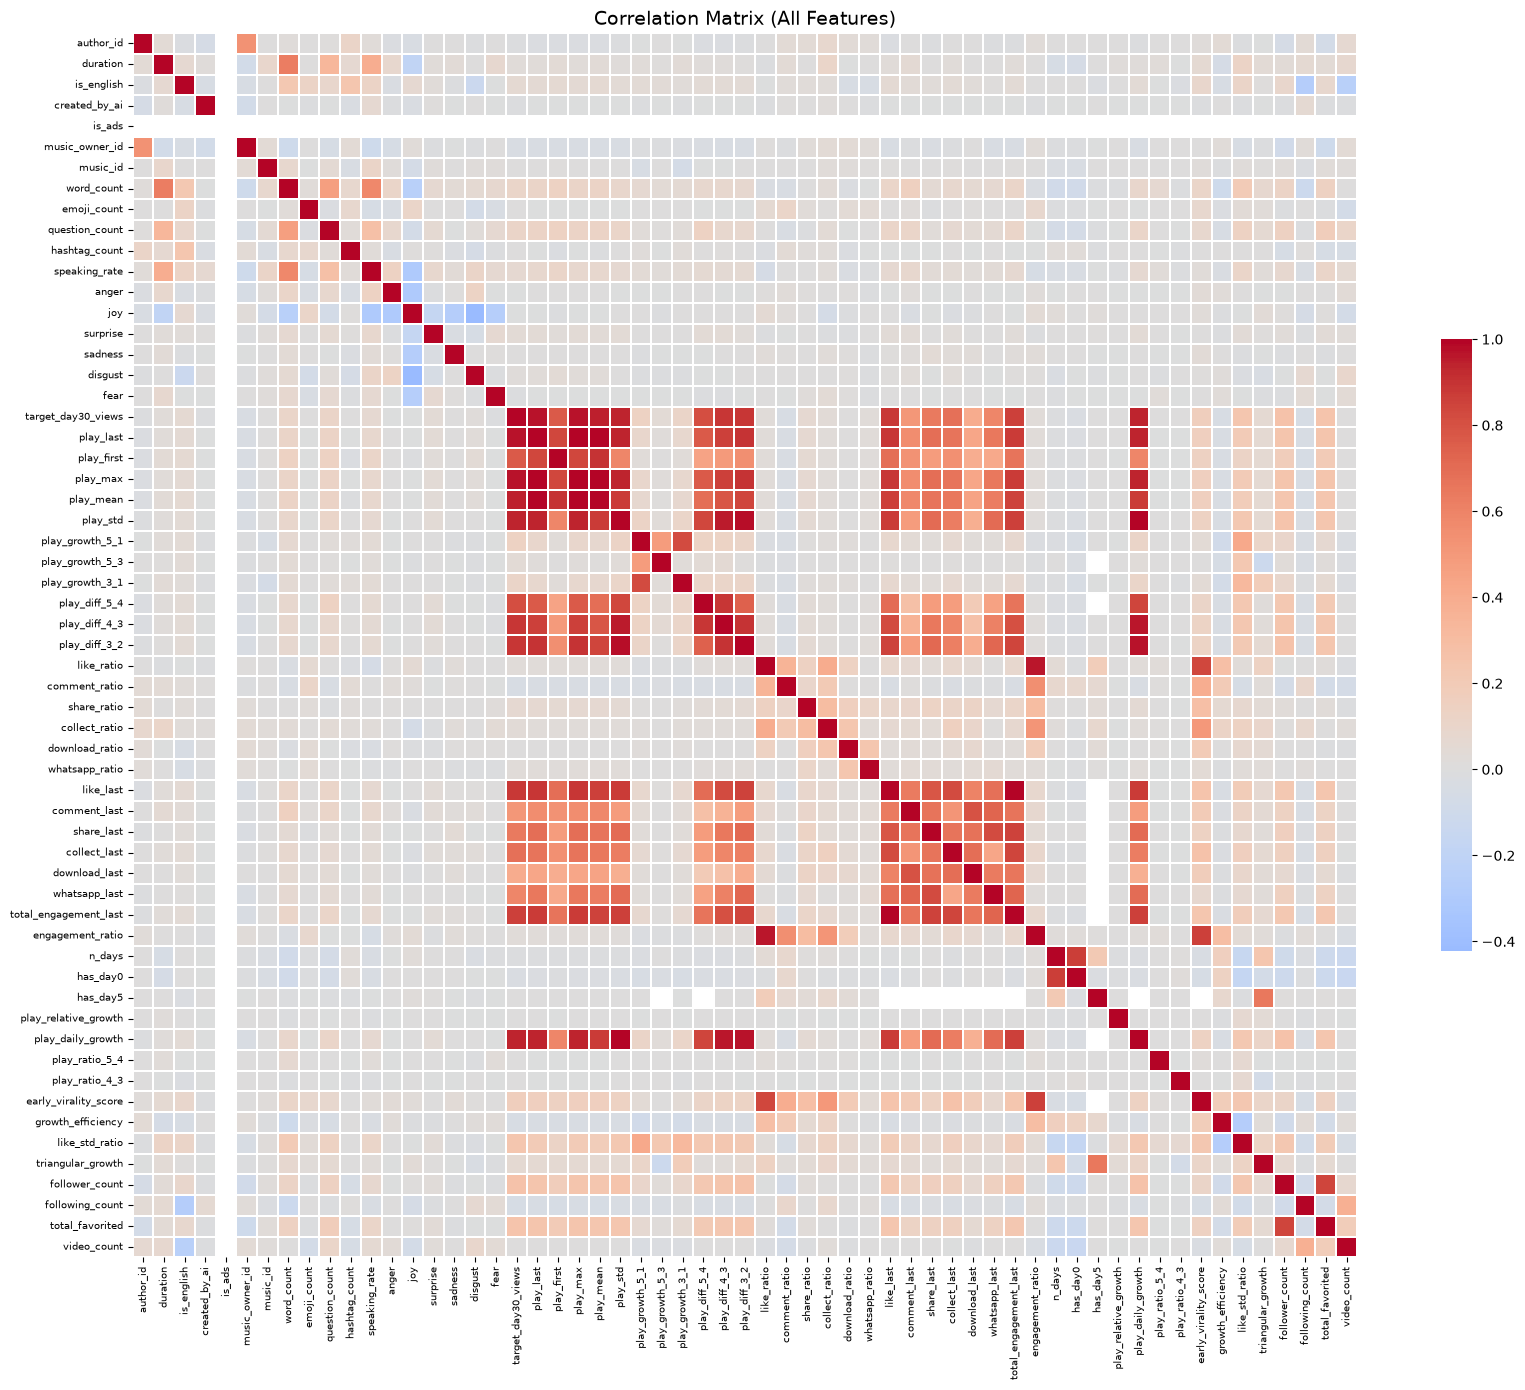

In [12]:
# ============================================
# CORRELATION MATRIX
# ============================================
print("=" * 60)
print("CORRELATION MATRIX")
print("=" * 60)

# Use df directly (which has target + features)
df_corr = df.copy()

# Select only numeric columns (drop categoricals + IDs)
numeric_cols = df_corr.select_dtypes(include=[np.number]).columns.tolist()
df_corr = df_corr[numeric_cols]

# Compute correlation
corr_matrix = df_corr.corr()

# Top correlations with target
print("\n" + "=" * 60)
print("TOP 25 FEATURES CORRELATED WITH TARGET")
print("=" * 60)
target_corr = (
    corr_matrix['target_day30_views']
    .drop('target_day30_views')
    .sort_values(ascending=False)
)
print(target_corr.head(25))

print("\n" + "=" * 60)
print("TOP 10 NEGATIVE CORRELATIONS")
print("=" * 60)
print(target_corr.tail(10))

# Plot heatmap
fig, ax = plt.subplots(figsize=(18, 14))
sns.heatmap(
    corr_matrix, 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.3,
    cbar_kws={"shrink": 0.5},
    xticklabels=True,
    yticklabels=True,
    ax=ax
)
ax.set_title('Correlation Matrix (All Features)', fontsize=14)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.show()

### Section 5.1 — Key Insight

Early engagement features show much stronger linear relationships with
Day-30 views than creator-level features.

**Top correlated features:**

| Feature | Correlation |
|---|---|
| `play_max` | 0.9707 |
| `play_last` | 0.9707 |
| `play_mean` | 0.9450 |
| `play_daily_growth` | 0.9385 |
| `play_std` | 0.9372 |

**Weak correlations:**
- `follower_count`: 0.2626
- `total_favorited`: 0.2543

**Conclusion:** The video's observed performance during the first five
days contains strong predictive information about its eventual Day-30
views. Creator features add smaller but useful signal.

### Section 5.2 — Outlier Analysis

We analyze the distribution of the target to understand:

- The concentration of views in the top videos
- The impact of extreme values on RMSE
- The effectiveness of simple baselines

In [13]:
# ============================================
# OUTLIERS ANALYSIS
# ============================================
print("=" * 60)
print("OUTLIERS ANALYSIS")
print("=" * 60)

# Use df['target_day30_views'] instead of y
y_series = df['target_day30_views']

# === 1. Target outliers ===
print("\n--- TARGET OUTLIERS ---")
y_sorted = y_series.sort_values(ascending=False)
print(f"Top 10 values:")
print(y_sorted.head(10))
print(f"\nTop 10 values as % of sum: {(y_sorted.head(10).sum() / y_series.sum() * 100):.2f}%")
print(f"Top 100 values as % of sum: {(y_sorted.head(100).sum() / y_series.sum() * 100):.2f}%")
print(f"Top 1000 values as % of sum: {(y_sorted.head(1000).sum() / y_series.sum() * 100):.2f}%")

# === 2. Quantiles ===
print("\n--- TARGET QUANTILES ---")
quantiles = [0.5, 0.75, 0.9, 0.95, 0.99, 0.999, 0.9999, 1.0]
for q in quantiles:
    print(f"Q{int(q*100):4d}: {y_series.quantile(q):>12,.0f}")

# === 3. IQR method for outliers ===
print("\n--- IQR OUTLIER METHOD ---")
Q1 = y_series.quantile(0.25)
Q3 = y_series.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
outliers_iqr = ((y_series < lower) | (y_series > upper)).sum()
print(f"Q1:    {Q1:>15,.0f}")
print(f"Q3:    {Q3:>15,.0f}")
print(f"IQR:   {IQR:>15,.0f}")
print(f"Lower: {lower:>15,.0f}")
print(f"Upper: {upper:>15,.0f}")
print(f"Outliers: {outliers_iqr:,} ({outliers_iqr/len(y_series)*100:.2f}%)")

# === 4. Impact on RMSE ===
print("\n--- IMPACT ON RMSE ---")
print(f"Mean:   {y_series.mean():>15,.0f}")
print(f"Median: {y_series.median():>15,.0f}")
print(f"Std:    {y_series.std():>15,.0f}")
print(f"\nIf we predict median for all:")
baseline_median = np.median(y_series)
rmse_baseline = np.sqrt(np.mean((y_series - baseline_median) ** 2))
print(f"  RMSE (median baseline): {rmse_baseline:,.0f}")

OUTLIERS ANALYSIS

--- TARGET OUTLIERS ---
Top 10 values:
video_id
7433609207527574826    16310546
7422053868328045855     7392530
7413481675545447711     7380943
7389650610129407278     7283358
7424283560334347562     7222986
7405034512733850926     5478572
7434730150987599134     5279577
7427538197061668126     4999018
7419457764008758570     4922634
7407238996801146155     4707681
Name: target_day30_views, dtype: int64

Top 10 values as % of sum: 20.24%
Top 100 values as % of sum: 58.43%
Top 1000 values as % of sum: 92.24%

--- TARGET QUANTILES ---
Q  50:          668
Q  75:        3,016
Q  90:       21,730
Q  95:       69,676
Q  99:      544,055
Q  99:    4,398,993
Q  99:    7,390,214
Q 100:   16,310,546

--- IQR OUTLIER METHOD ---
Q1:                344
Q3:              3,016
IQR:             2,672
Lower:          -3,665
Upper:           7,025
Outliers: 2,138 (17.82%)

--- IMPACT ON RMSE ---
Mean:            29,229
Median:             668
Std:            275,213

If we predict med

### Section 5.2 — Key Insight

The target distribution is dominated by a small number of very
high-view videos.

**Concentration:**
- **Top 10 videos**: 20.24% of total views
- **Top 100 videos**: 58.43% of total views
- **Top 1,000 videos**: 92.24% of total views

**Quantiles:**
- Q90 = 21,730 views
- Q99 = 544,055 views
- Max = 16,310,546 views

**Implication:** A small high-view segment has a large effect on RMSE.
This motivates testing modeling strategies that explicitly account for
the upper tail, such as two-stage modeling with a classifier for
"viral" videos.

## 6. Save Clean Dataset

We save the final merged dataset for the modeling stage.
The output includes all video-level features plus the target.

In [14]:
# ============================================
# SAVE CLEAN DATASET FOR MODELING
# ============================================
import os
os.makedirs('../data/processed', exist_ok=True)

df.to_csv('../data/processed/modeling_table.csv', index=True)

print("=" * 60)
print("SAVED CLEAN DATASET FOR MODELING")
print("=" * 60)
print(f"Shape: {df.shape}")
print(f"Path: ../data/processed/modeling_table.csv")
print(f"\nAll columns ({len(df.columns)}):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:3d}. {col}")

# === Verify ===
print(f"\n--- Verification ---")
print(f"Index name: {df.index.name}")
print(f"Target column present: {'target_day30_views' in df.columns}")
print(f"Total NaN values: {df.isnull().sum().sum()}")
print(f"\nColumns by type:")
print(df.dtypes.value_counts())

SAVED CLEAN DATASET FOR MODELING
Shape: (12000, 66)
Path: ../data/processed/modeling_table.csv

All columns (66):
    1. author_id
    2. create_time
    3. create_date
    4. duration
    5. ratio
    6. desc_language
    7. is_english
    8. created_by_ai
    9. is_ads
   10. music_selected_from
   11. music_author
   12. music_owner_id
   13. music_id
   14. word_count
   15. emoji_count
   16. question_count
   17. hashtag_count
   18. speaking_rate
   19. topic
   20. anger
   21. joy
   22. surprise
   23. sadness
   24. disgust
   25. fear
   26. target_day30_views
   27. play_last
   28. play_first
   29. play_max
   30. play_mean
   31. play_std
   32. play_growth_5_1
   33. play_growth_5_3
   34. play_growth_3_1
   35. play_diff_5_4
   36. play_diff_4_3
   37. play_diff_3_2
   38. like_ratio
   39. comment_ratio
   40. share_ratio
   41. collect_ratio
   42. download_ratio
   43. whatsapp_ratio
   44. like_last
   45. comment_last
   46. share_last
   47. collect_last
   48. 

## 7. Conclusions & Next Steps

### Data Summary

- **Train**: 12,000 videos × 27 columns
- **Test**: 3,001 videos × 26 columns
- **Engagement**: 79,489 rows (15,000 unique videos)
- **Creators**: 252,166 rows (1,671 unique creators)

### Key Findings

1. **Target is heavily right-skewed** (skewness = 29.13).
   RMSE will be sensitive to outliers.

2. **Day 0 engagement is missing for ~62% of videos**.
   Day 1 is a more reliable "first" observation.

3. **Creator features are heavily skewed** (follower_count up to 12.5M).
   Log transforms may help.

4. **As-of merge for creators** avoids future leakage.

5. **Top 100 videos = 58% of total views**.
   The upper tail dominates the target distribution.

### Feature Engineering Summary

The final feature set includes:

- **Engagement level**: `play_last`, `like_last`, `comment_last`, ...
- **Growth ratios**: `play_growth_5_1`, `play_growth_5_3`, ...
- **Interaction ratios**: `like_ratio`, `share_ratio`, `comment_ratio`, ...
- **Creator features**: `follower_count`, `total_favorited`, `video_count`
- **Metadata**: `duration`, `topic`, `is_english`, ...
- **Completeness**: `n_days`, `has_day0`, `has_day5`

### Next Steps

1. Build `02_modeling.ipynb`.
2. Test baseline models (LightGBM, CatBoost).
3. Test target transformations (log1p, sqrt, cbrt).
4. Build a leakage-safe Two-Stage model.
5. Produce the final submission.